In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore')
import warnings
warnings.filterwarnings("ignore")

# pd.set_option("display.width", 150) 
# pd.set_option("display.precision", 3)
# plt.rcParams["figure.figsize"] = (9, 4.2)
# plt.rcParams["axes.grid"] = True
# plt.rcParams["grid.alpha"] = 0.3
# plt.rcParams["figure.dpi"] = 110

SEED = 42

In [28]:
df = pd.read_csv("online_shoppers_intention.csv")
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [29]:
df.shape

(12330, 18)

# EDA

## Первичная обработка

In [30]:
print('Все колонки:', df.columns.tolist())
df.info()

Все колонки: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9 

In [31]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [32]:
target_feature = 'Revenue'

categ_features = [
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Month",
    "Weekend"
]

quant_features = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

print(set(categ_features + quant_features + [target_feature]) == set(df.columns.to_list()) and len(categ_features) + len(quant_features) + 1 == len(df.columns.to_list()))

True


In [33]:
print('Пропусков по столбцам')
print(f'{df.isnull().sum()}')

Пропусков по столбцам
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [34]:
df[df.duplicated()].sort_values(list(df.columns))

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
10751,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
11801,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291,0,0.0,0,0.0,2,0.0,0.2,0.2,0.0,0.0,Mar,2,2,1,1,Returning_Visitor,False,False
659,0,0.0,0,0.0,2,0.0,0.2,0.2,0.0,0.0,Mar,2,5,1,1,Returning_Visitor,False,False
4552,0,0.0,0,0.0,2,0.0,0.2,0.2,0.0,0.0,May,2,2,2,3,Returning_Visitor,False,False
5199,0,0.0,0,0.0,2,0.0,0.2,0.2,0.0,0.0,May,2,2,2,3,Returning_Visitor,False,False


In [35]:
total_duplicates = df.duplicated().sum()
print(f"Всего дублирующихся строк: {total_duplicates}")
print(f"Процент от выборки {(total_duplicates / df.shape[0] * 100):.2f}%")
# df.drop_duplicates(inplace=True)

Всего дублирующихся строк: 125
Процент от выборки 1.01%


In [36]:
df.drop_duplicates(inplace=True)

## Распределение

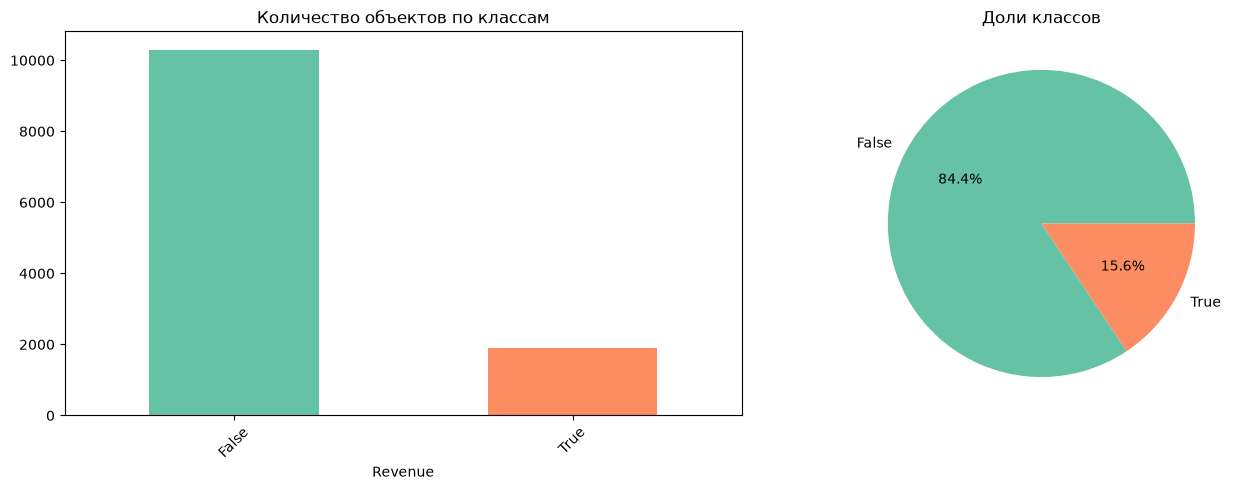

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_feature].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target_feature].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

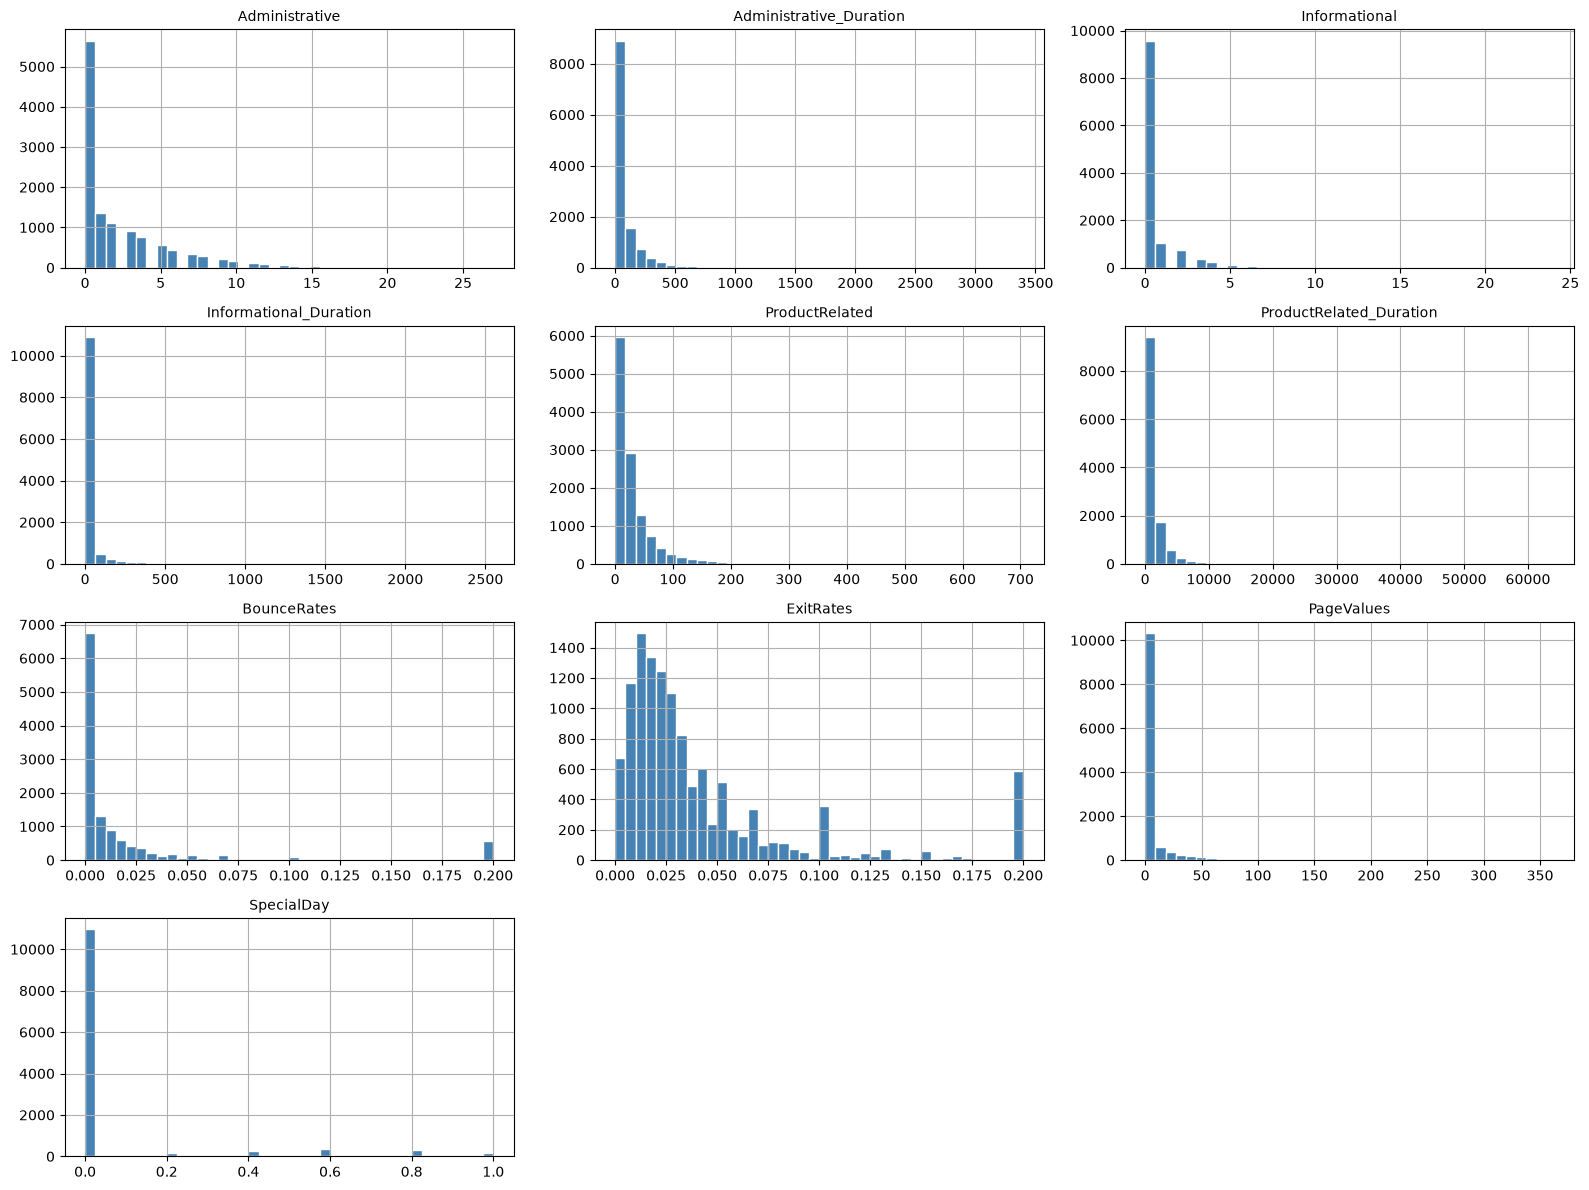

In [38]:
n_cols = len(quant_features)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(quant_features):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(quant_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [39]:
df[list(quant_features)].describe(percentiles=[.05, .25, .50, .75, .95, .99]).T

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Administrative,12205.0,2.338878,3.330436,0.0,0.000000,0.000000,1.000000,4.000000,9.000000,14.000000,27.000000
Administrative_Duration,12205.0,81.646331,177.491845,0.0,0.000000,0.000000,9.000000,94.700000,352.208095,838.704889,3398.750000
Informational,12205.0,0.508726,1.275617,0.0,0.000000,0.000000,0.000000,0.000000,3.000000,6.000000,24.000000
Informational_Duration,12205.0,34.825454,141.424807,0.0,0.000000,0.000000,0.000000,0.000000,199.000000,722.379200,2549.375000
ProductRelated,12205.0,32.045637,44.593649,0.0,2.000000,8.000000,18.000000,38.000000,110.000000,221.000000,705.000000
ProductRelated_Duration,12205.0,1206.982457,1919.601400,0.0,0.000000,193.000000,608.942857,1477.154762,4312.956282,8704.271573,63973.522230
BounceRates,12205.0,0.020370,0.045255,0.0,0.000000,0.000000,0.002899,0.016667,0.149333,0.200000,0.200000
ExitRates,12205.0,0.041466,0.046163,0.0,0.004545,0.014231,0.025000,0.048529,0.173714,0.200000,0.200000
PageValues,12205.0,5.949574,18.653671,0.0,0.000000,0.000000,0.000000,0.000000,38.301457,86.108689,361.763742
SpecialDay,12205.0,0.061942,0.199666,0.0,0.000000,0.000000,0.000000,0.000000,0.600000,1.000000,1.000000


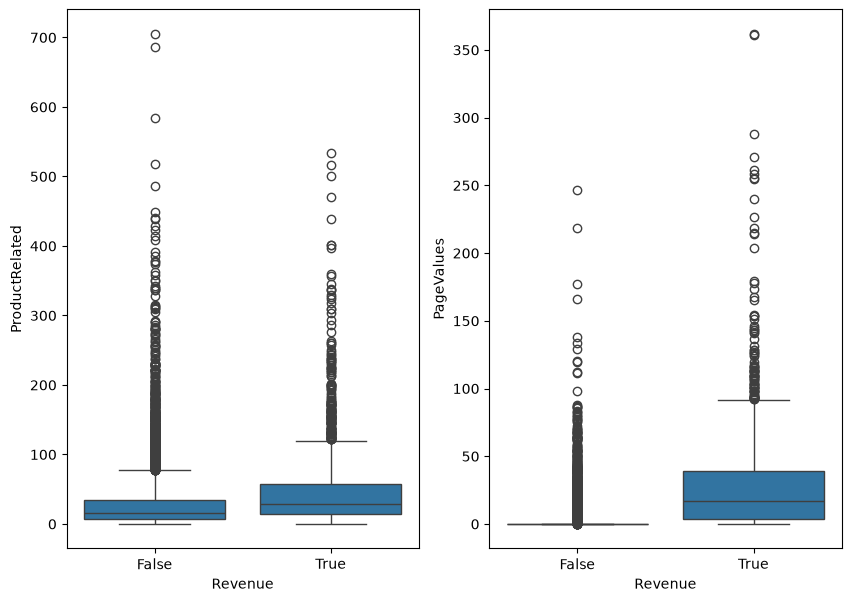

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(10, 7))

sns.boxplot(df, x=target_feature, y='ProductRelated', ax=ax[0])
sns.boxplot(df, x=target_feature, y='PageValues', ax=ax[1])

plt.show()

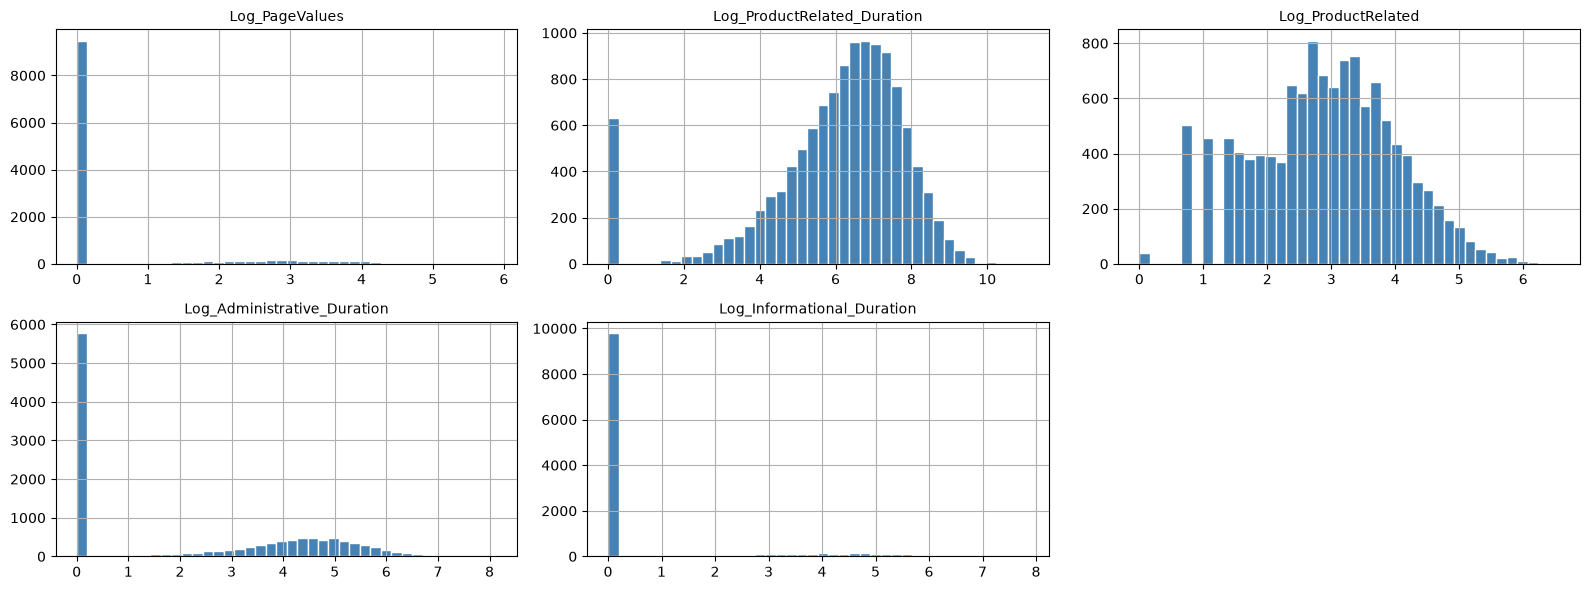

In [41]:
log_features = [
   'PageValues', 
   'ProductRelated_Duration',
   'ProductRelated',
   'Administrative_Duration',
   'Informational_Duration',
]

n_cols = len(log_features)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(log_features):
    np.log1p(df[col]).hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title('Log_' + col, fontsize=10)

for j in range(len(log_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

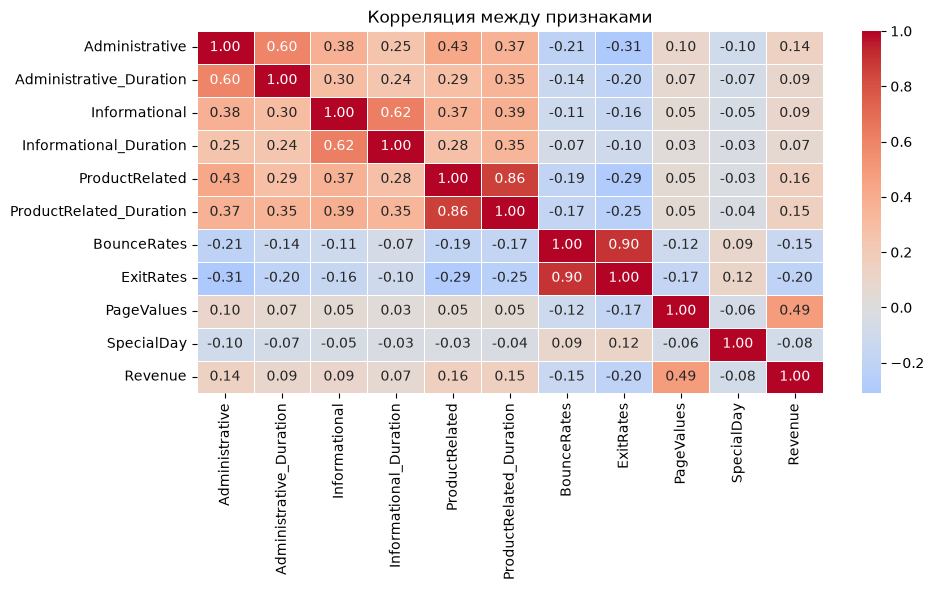

In [42]:
plt.figure(figsize=(10, 6))
corr = df[quant_features + [target_feature]].corr()
# mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

## Категориальные фичи

In [43]:
categ_features

['OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType',
 'Month',
 'Weekend']

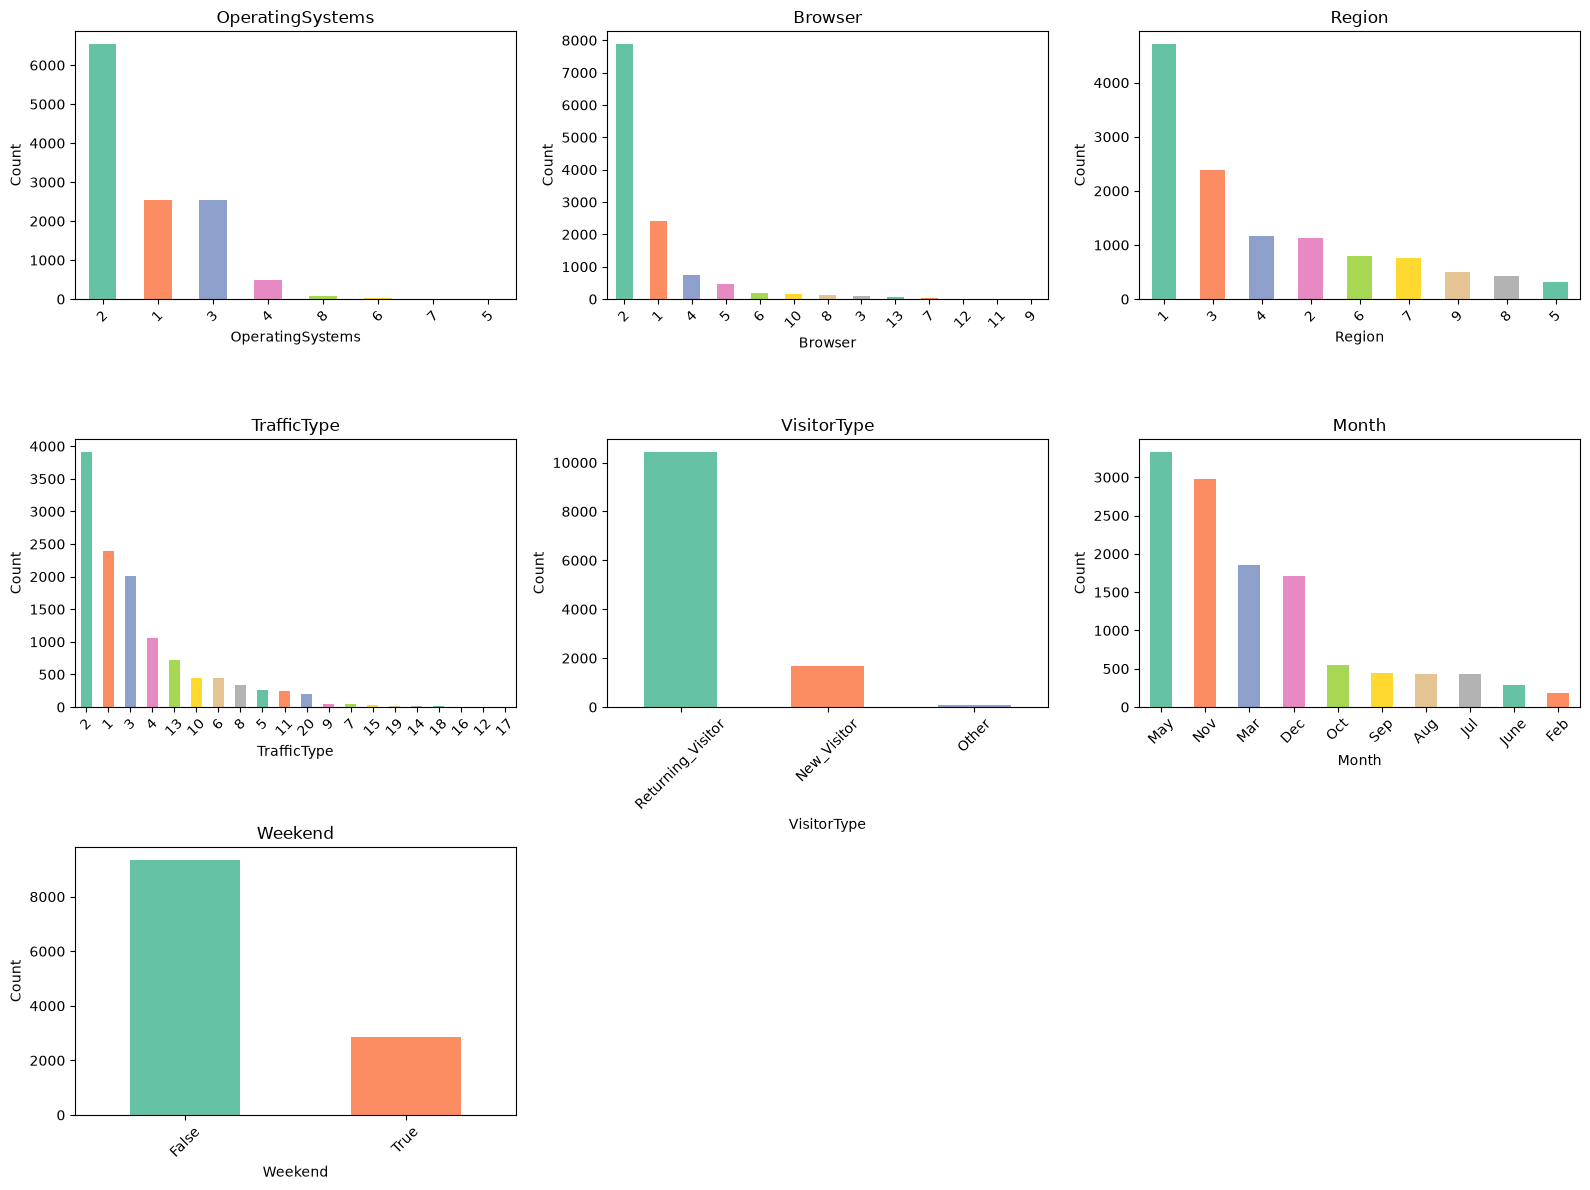

In [44]:
n_cols = 3
n_rows = (len(categ_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categ_features):
    df[col].value_counts().plot.bar(ax=axes[i], color=sns.color_palette('Set2'))
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')

for j in range(len(categ_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

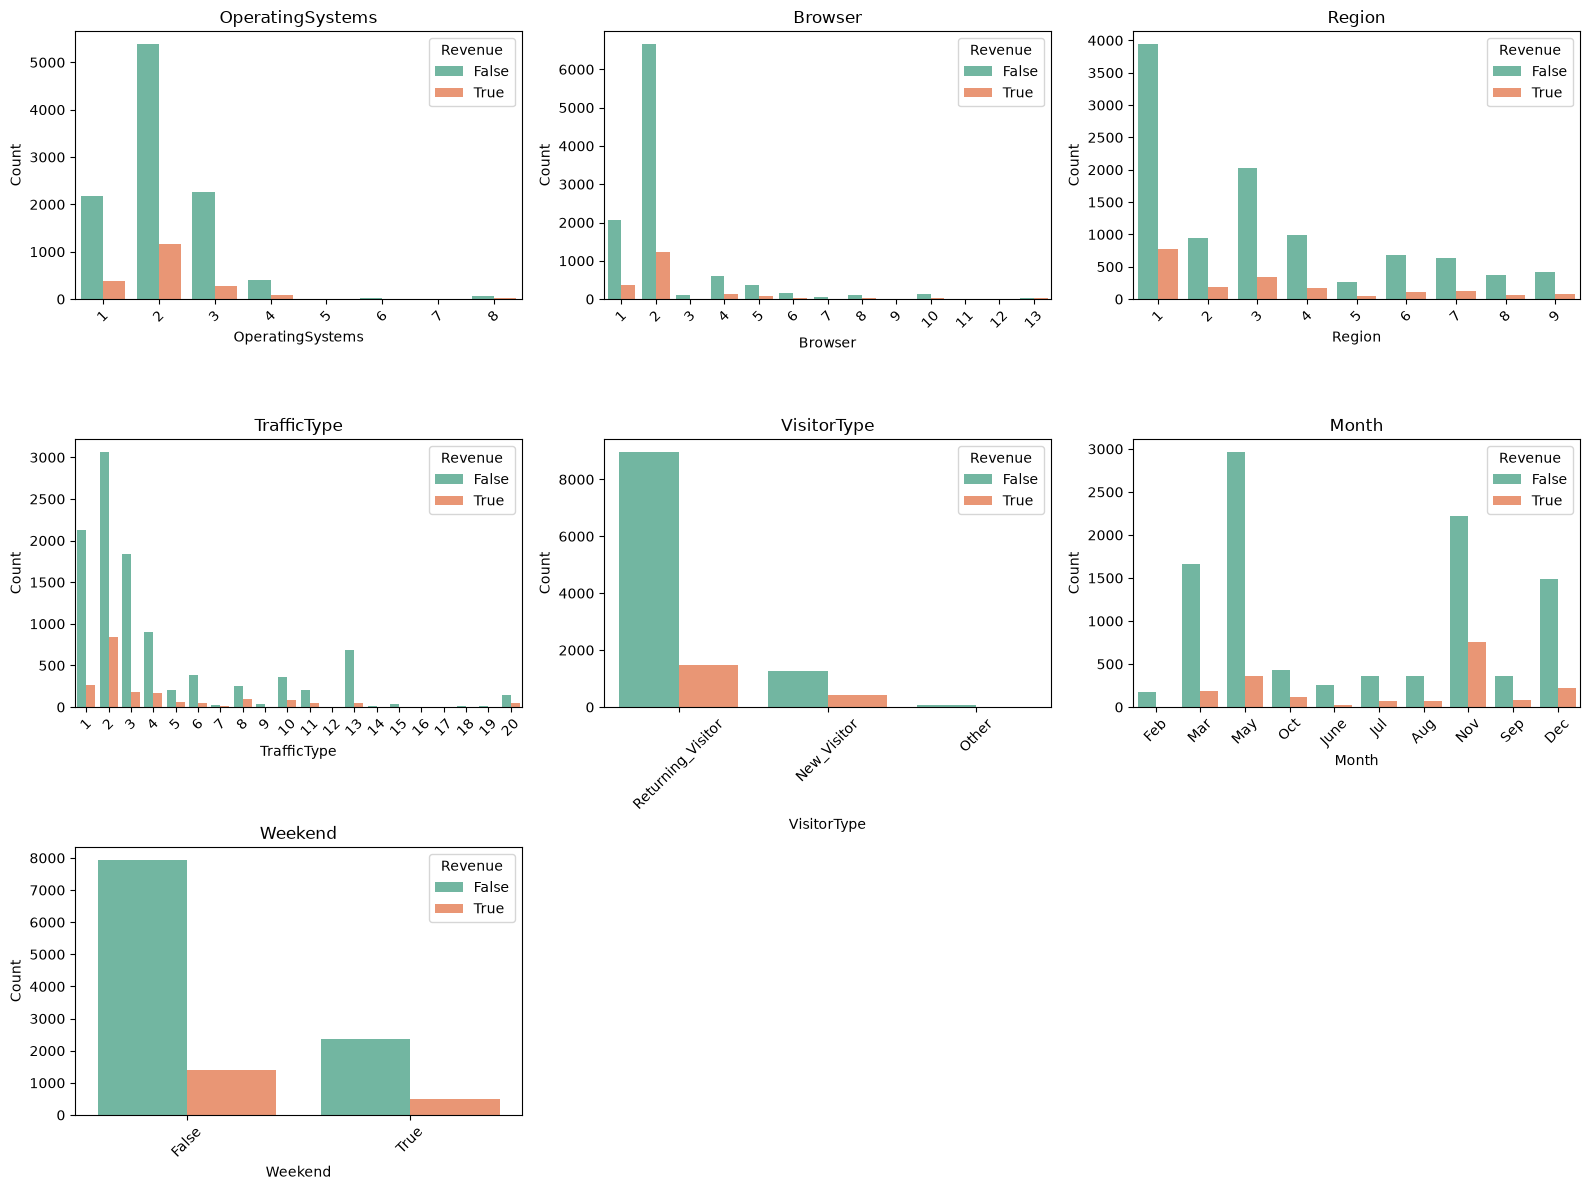

In [45]:
n_cols = 3
n_rows = (len(categ_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categ_features):
    sns.countplot(data=df, x=col, hue=target_feature, ax=axes[i], palette='Set2')
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')
    axes[i].legend(title=target_feature)

for j in range(len(categ_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Feature engineering

In [46]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [47]:
X = df.drop(columns=target_feature)
y = df[target_feature].astype(int)


In [48]:
X.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
dtype: object

In [49]:
binary_feature = [
    'Weekend'
]
for i in binary_feature:
    categ_features.remove(i)

X[binary_feature] = X[binary_feature].astype(int)
X[categ_features] = X[categ_features].astype('str')
X.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems               str
Browser                        str
Region                         str
TrafficType                    str
VisitorType                    str
Weekend                      int64
dtype: object

In [50]:
for col in (categ_features):
    counts = X[col].value_counts()
    rare_categories = counts[counts < 10].index

    X.loc[
        X[col].isin(rare_categories),
        col
    ] = 'Other'

In [51]:
log_features = [
   'PageValues', 
   'ProductRelated_Duration',
   'ProductRelated',
   'Administrative_Duration',
   'Informational_Duration',
]

preprocessor = ColumnTransformer(
    transformers=[
        ('log', FunctionTransformer(np.log1p), log_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categ_features)
    ],
    remainder='passthrough'
)